# NB09A — Ensemble Extension (Holopainen & Sarlin, 2017)

**Purpose:** Implement model averaging following Holopainen & Sarlin (2017), who demonstrate  
that combining predicted probabilities across classifiers consistently produces more stable  
and robust early-warning forecasts than selecting a single best model.

## Primary ensemble

| Label | Models averaged | Data | Status |
|-------|----------------|------|--------|
| **E1** | M2-matched + M3 | Stage 2, 2003–2020 | **Primary result** |

## Exploratory cross-stage ensembles (excluded from primary results)

| Label | Models averaged | Limitation |
|-------|----------------|------------|
| E2 | M2 (S1) + M2-matched + M3 | Different training windows — not a controlled comparison |
| E3 | M1 + M2 (S1) + M2-matched + M3 | M1 miscalibration in overlap window disqualifies |

## Methodological note on pooled OOS evaluation

This notebook combines model predictions after pooling OOS outputs across expanding-window  
folds. This is the standard evaluation methodology in the EWS literature (Jordà, Schularick  
and Taylor, 2017; Holopainen and Sarlin, 2017) and is appropriate for ex-post academic  
assessment of discrimination performance. It is distinct from fold-by-fold combination,  
which applies to real-time deployment where future predictions must be generated before  
test outcomes are observed. In the present setting, all OOS predictions are already  
generated by NB05A under strict temporal ordering; their post-hoc combination for  
evaluation purposes does not constitute leakage.

## Calibration note

M3 probabilities are isotonically calibrated within each expanding-window fold in NB05A  
via CalibratedClassifierCV. M2-matched uses Random Forest with class-weighted training,  
which produces reasonably calibrated probabilities. Both Brier Scores are comparable  
(0.060 and 0.061). E1 Brier (0.057) is lower than either component, confirming that  
averaging does not degrade calibration. No additional pre-averaging calibration step  
is required.

**Inputs:** `data/processed/augmented_analysis/oos_predictions_stage1.csv`  
           `data/processed/augmented_analysis/oos_predictions_stage2.csv`  
**Outputs:** `data/processed/augmented_analysis/oos_predictions_ensemble.csv`  
             `figures/augmented_analysis/NB09A_ensemble_stage2.png`  
             `figures/augmented_analysis/NB09A_ensemble_disagreement.png`

---

## Cell 1 — Imports and paths

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay
)

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
OUT_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
FIG_DIR = BASE / 'figures' / 'augmented_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

S1_CSV = OUT_DIR / 'oos_predictions_stage1.csv'
S2_CSV = OUT_DIR / 'oos_predictions_stage2.csv'

assert S1_CSV.exists(), f'Stage 1 OOS file not found: {S1_CSV}\nRun NB05A first.'
assert S2_CSV.exists(), f'Stage 2 OOS file not found: {S2_CSV}\nRun NB05A first.'

TARGET       = 'target_h2'
RANDOM_STATE = 42
N_BOOTSTRAP  = 1000

print('✅  Imports and paths OK.')
print(f'   Stage 1 OOS : {S1_CSV}')
print(f'   Stage 2 OOS : {S2_CSV}')

✅  Imports and paths OK.
   Stage 1 OOS : C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_stage1.csv
   Stage 2 OOS : C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_stage2.csv


## Cell 2 — Load OOS predictions

In [5]:
s1 = pd.read_csv(S1_CSV)
s2 = pd.read_csv(S2_CSV)

# Drop burn-in NaN rows (1989-1992 for Stage 1; 2003-2006 for Stage 2)
s1_eval = s1.dropna(subset=['prob_m1', 'prob_m2']).copy()
s2_eval = s2.dropna(subset=['prob_m2m', 'prob_m3']).copy()

print('Stage 1 OOS (eval rows only)')
print(f'  Rows: {len(s1_eval)}  |  Crisis events: {int(s1_eval[TARGET].sum())}')
print(f'  Eval years: {s1_eval["year"].min()}–{s1_eval["year"].max()}')
print()
print('Stage 2 OOS (eval rows only)')
print(f'  Rows: {len(s2_eval)}  |  Crisis events: {int(s2_eval[TARGET].sum())}')
print(f'  Eval years: {s2_eval["year"].min()}–{s2_eval["year"].max()}')

Stage 1 OOS (eval rows only)
  Rows: 467  |  Crisis events: 28
  Eval years: 1993–2018

Stage 2 OOS (eval rows only)
  Rows: 215  |  Crisis events: 11
  Eval years: 2007–2018


## Cell 3 — Build E1: Stage 2 ensemble (M2-matched + M3)

Equal-weighted average of M2-matched and M3 OOS probabilities.  
Both models were trained on identical 2003–2020 data under identical expanding-window folds.  

Equal weights are used throughout. Performance-weighted variants are not implemented  
because any weighting scheme derived from the same OOS pool used for evaluation  
would constitute circular in-sample selection of weights (data leakage in the  
weight-estimation step).

In [7]:
e1 = s2_eval[['year', 'iso', TARGET, 'prob_m2m', 'prob_m3']].copy()
e1['prob_e1'] = (e1['prob_m2m'] + e1['prob_m3']) / 2

print('E1 — Stage 2 ensemble (equal-weighted average: M2-matched + M3)')
print(f'  Observations : {len(e1)}')
print(f'  Crisis events: {int(e1[TARGET].sum())}  (base rate {e1[TARGET].mean():.4f})')
print(f'  Eval years   : {e1["year"].min()}–{e1["year"].max()}')
print()
print('  Probability summary:')
print(e1[['prob_m2m', 'prob_m3', 'prob_e1']].describe().round(4).to_string())

E1 — Stage 2 ensemble (equal-weighted average: M2-matched + M3)
  Observations : 215
  Crisis events: 11  (base rate 0.0512)
  Eval years   : 2007–2018

  Probability summary:
       prob_m2m   prob_m3   prob_e1
count  215.0000  215.0000  215.0000
mean     0.1777    0.1665    0.1721
std      0.1727    0.2126    0.1834
min      0.0049    0.0000    0.0203
25%      0.0557    0.0356    0.0581
50%      0.1067    0.0889    0.0917
75%      0.2356    0.1786    0.1953
max      0.7377    1.0000    0.8658


## Cell 4 — Model disagreement analysis

Holopainen & Sarlin (2017) motivate ensemble averaging as a response to model uncertainty:  
when individual models disagree, averaging reduces instability in the combined forecast.  
When models agree closely, the ensemble adds primarily variance smoothing.

This cell quantifies disagreement between M2-matched and M3 across the evaluation window,  
distinguishing high-probability observations (potential crisis signals) from the  
background population.

In [9]:
corr = e1['prob_m2m'].corr(e1['prob_m3'])
e1['disagreement'] = (e1['prob_m2m'] - e1['prob_m3']).abs()
mean_disagree = e1['disagreement'].mean()
max_disagree  = e1['disagreement'].max()

print('=== Model Disagreement Analysis: M2-matched vs M3 ===')
print()
print(f'  Pearson correlation (prob_m2m, prob_m3) : {corr:.4f}')
print(f'  Mean |prob_m2m - prob_m3|               : {mean_disagree:.4f}')
print(f'  Max  |prob_m2m - prob_m3|               : {max_disagree:.4f}')
print()
print('  Disagreement by outcome (crisis vs no crisis):')
print(e1.groupby(TARGET)['disagreement'].agg(['mean','std','max']).round(4).to_string())
print()

# High-signal observations — top decile of the higher of the two model probs
threshold = e1[['prob_m2m','prob_m3']].max(axis=1).quantile(0.9)
high_signal = e1[(e1['prob_m2m'] >= threshold) | (e1['prob_m3'] >= threshold)]
print(f'  High-signal observations (top-decile threshold = {threshold:.3f}):')
print(f'    Count: {len(high_signal)}  |  Crisis events: {int(high_signal[TARGET].sum())}')
print(f'    Mean disagreement: {high_signal["disagreement"].mean():.4f}')
print(f'    Max  disagreement: {high_signal["disagreement"].max():.4f}')
print()

# Top disagreement cases
top_disagree = (
    e1[['year','iso',TARGET,'prob_m2m','prob_m3','prob_e1','disagreement']]
    .sort_values('disagreement', ascending=False).head(10)
)
print('  Top 10 highest-disagreement observations:')
print(top_disagree.to_string(index=False))
print()
print('Interpretation note:')
print('  High correlation overall -> models share common signal structure.')
print('  If disagreement is higher at crisis=1 rows than crisis=0 rows,')
print('  averaging is most valuable precisely where uncertainty is highest —')
print('  the core motivation in Holopainen & Sarlin (2017).')

=== Model Disagreement Analysis: M2-matched vs M3 ===

  Pearson correlation (prob_m2m, prob_m3) : 0.8107
  Mean |prob_m2m - prob_m3|               : 0.0872
  Max  |prob_m2m - prob_m3|               : 0.5524

  Disagreement by outcome (crisis vs no crisis):
             mean     std     max
target_h2                        
0          0.0800  0.0795  0.4877
1          0.2204  0.1488  0.5524

  High-signal observations (top-decile threshold = 0.562):
    Count: 22  |  Crisis events: 7
    Mean disagreement: 0.2532
    Max  disagreement: 0.5524

  Top 10 highest-disagreement observations:
 year iso  target_h2  prob_m2m  prob_m3  prob_e1  disagreement
 2007 PRT          1  0.417772 0.970151 0.693961      0.552379
 2008 ESP          0  0.737737 0.250000 0.493869      0.487737
 2007 CAN          0  0.292323 0.750000 0.521162      0.457677
 2008 JPN          0  0.133765 0.562500 0.348133      0.428735
 2008 NOR          0  0.588844 1.000000 0.794422      0.411156
 2007 FRA          1  0.6737

## Cell 5 — Disagreement visualisation

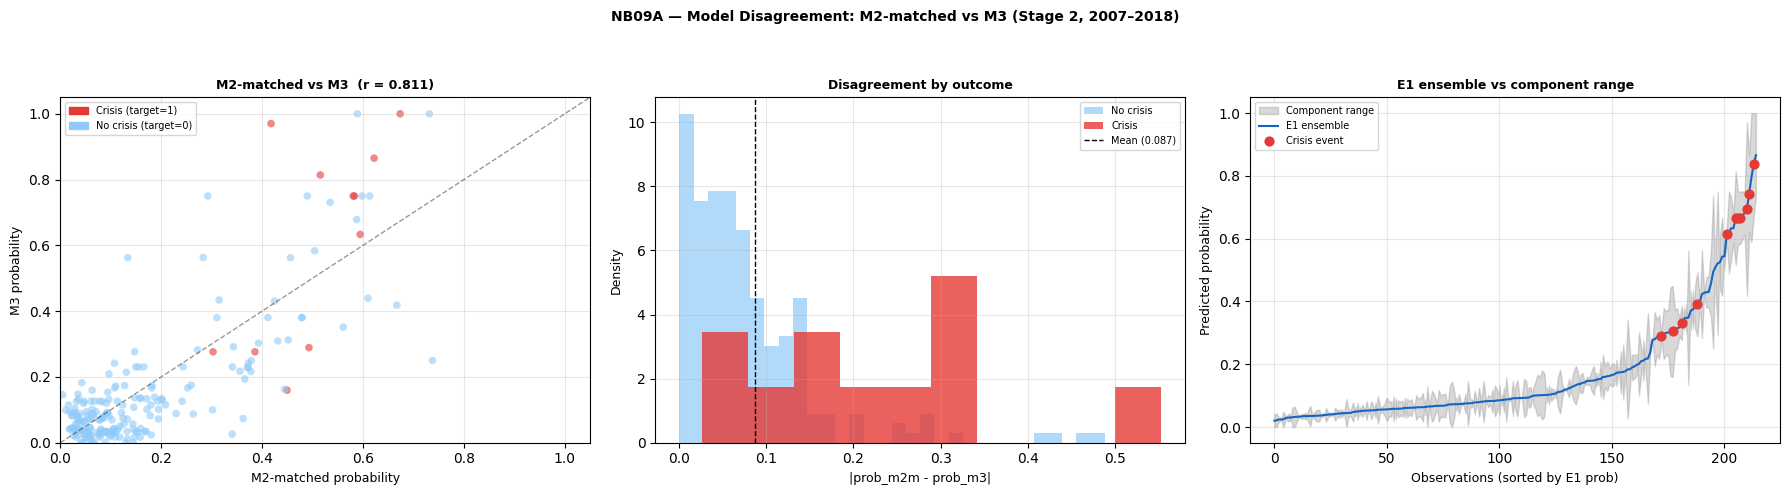

Saved -> C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\NB09A_ensemble_disagreement.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'NB09A — Model Disagreement: M2-matched vs M3 (Stage 2, 2007–2018)',
    fontweight='bold', fontsize=10
)

crisis_col = e1[TARGET].map({0: '#90CAF9', 1: '#E53935'})

# Panel 1: scatter M2-matched vs M3
ax = axes[0]
ax.scatter(e1['prob_m2m'], e1['prob_m3'], c=crisis_col, alpha=0.6, s=30, edgecolors='none')
lims = [0, max(e1['prob_m2m'].max(), e1['prob_m3'].max()) * 1.05]
ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1)
ax.set_xlabel('M2-matched probability', fontsize=9)
ax.set_ylabel('M3 probability', fontsize=9)
ax.set_title(f'M2-matched vs M3  (r = {corr:.3f})', fontweight='bold', fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(handles=[
    Patch(color='#E53935', label='Crisis (target=1)'),
    Patch(color='#90CAF9', label='No crisis (target=0)'),
], fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)

# Panel 2: disagreement distribution by outcome
ax2 = axes[1]
crisis_dis    = e1.loc[e1[TARGET]==1, 'disagreement']
noncrisis_dis = e1.loc[e1[TARGET]==0, 'disagreement']
ax2.hist(noncrisis_dis, bins=30, color='#90CAF9', alpha=0.7, label='No crisis', density=True)
ax2.hist(crisis_dis,    bins=10, color='#E53935', alpha=0.8, label='Crisis',    density=True)
ax2.axvline(mean_disagree, color='black', linestyle='--', linewidth=1,
            label=f'Mean ({mean_disagree:.3f})')
ax2.set_xlabel('|prob_m2m - prob_m3|', fontsize=9)
ax2.set_ylabel('Density', fontsize=9)
ax2.set_title('Disagreement by outcome', fontweight='bold', fontsize=9)
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# Panel 3: ensemble vs component range (sorted by ensemble probability)
ax3 = axes[2]
sorted_idx = e1['prob_e1'].argsort().values
x = np.arange(len(sorted_idx))
ax3.fill_between(x,
    e1['prob_m2m'].values[sorted_idx],
    e1['prob_m3'].values[sorted_idx],
    alpha=0.3, color='grey', label='Component range')
ax3.plot(x, e1['prob_e1'].values[sorted_idx],
         color='#1565C0', linewidth=1.5, label='E1 ensemble')
crisis_pos = np.where(e1[TARGET].values[sorted_idx] == 1)[0]
ax3.scatter(crisis_pos,
            e1['prob_e1'].values[sorted_idx][crisis_pos],
            color='#E53935', zorder=5, s=40, label='Crisis event')
ax3.set_xlabel('Observations (sorted by E1 prob)', fontsize=9)
ax3.set_ylabel('Predicted probability', fontsize=9)
ax3.set_title('E1 ensemble vs component range', fontweight='bold', fontsize=9)
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
fig_path_dis = FIG_DIR / 'NB09A_ensemble_disagreement.png'
fig.savefig(fig_path_dis, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path_dis}')

## Cell 6 — Metric helper with bootstrap CIs

In [13]:
def compute_metrics(y_true, y_prob, label, n_boot=N_BOOTSTRAP, rng_seed=RANDOM_STATE):
    """AUROC, AUPRC, Brier with bootstrap 95% CI (1000 resamples)."""
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    base  = y_true.mean()

    rng = np.random.default_rng(rng_seed)
    n   = len(y_true)
    boot_auroc, boot_auprc = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb, pb = y_true[idx], y_prob[idx]
        if yb.sum() == 0 or yb.sum() == len(yb):
            continue
        boot_auroc.append(roc_auc_score(yb, pb))
        boot_auprc.append(average_precision_score(yb, pb))

    ci_auroc = (np.percentile(boot_auroc, 2.5), np.percentile(boot_auroc, 97.5))
    ci_auprc = (np.percentile(boot_auprc, 2.5), np.percentile(boot_auprc, 97.5))

    return {
        'Label': label,
        'AUROC': auroc, 'AUROC_lo': ci_auroc[0], 'AUROC_hi': ci_auroc[1],
        'AUPRC': auprc, 'AUPRC_lo': ci_auprc[0], 'AUPRC_hi': ci_auprc[1],
        'Brier': brier, 'Base_rate': base, 'AUPRC_lift': auprc / base
    }

print(f'Metric helper defined.  Bootstrap resamples: {N_BOOTSTRAP}')

Metric helper defined.  Bootstrap resamples: 1000


## Cell 7 — Primary results: E1 vs component models

The only fully controlled comparison in this notebook. All three model probability  
series are evaluated on identical observations derived from the Stage 2 expanding-window.

In [15]:
y_e1 = e1[TARGET].values

ctx_a_results = [
    compute_metrics(y_e1, e1['prob_m2m'].values, 'M2-matched (S2)'),
    compute_metrics(y_e1, e1['prob_m3'].values,  'M3 XGB+FinBERT (S2)'),
    compute_metrics(y_e1, e1['prob_e1'].values,  'E1: equal-weighted avg(M2-matched, M3)'),
]
df_a = pd.DataFrame(ctx_a_results)

w = 108
print('=' * w)
print(' PRIMARY RESULTS — Stage 2 ensemble vs component models')
print(f' Obs: {len(e1)}  |  Crisis: {int(e1[TARGET].sum())}  |  Base rate: {e1[TARGET].mean():.4f}')
print(f' All metrics subject to single-episode evaluation constraint (Section 4.1).')
print('=' * w)
print(f' {"Model":<45} {"AUROC":>7} {"95% CI":>14} {"AUPRC":>7} {"95% CI":>14} {"Brier":>7} {"Lift":>5}')
print('-' * w)
for _, r in df_a.iterrows():
    ci_a = f'[{r.AUROC_lo:.3f},{r.AUROC_hi:.3f}]'
    ci_p = f'[{r.AUPRC_lo:.3f},{r.AUPRC_hi:.3f}]'
    print(f' {r.Label:<45} {r.AUROC:>7.4f} {ci_a:>14} {r.AUPRC:>7.4f} {ci_p:>14} {r.Brier:>7.4f} {r.AUPRC_lift:>5.1f}x')
print('=' * w)
print()

idx = df_a.set_index('Label')
m2m_r = idx.loc['M2-matched (S2)']
m3_r  = idx.loc['M3 XGB+FinBERT (S2)']
e1_r  = idx.loc['E1: equal-weighted avg(M2-matched, M3)']

print('Key deltas — AUPRC (primary metric):')
print(f'  E1 vs M2-matched : {e1_r.AUPRC - m2m_r.AUPRC:+.4f}  ({100*(e1_r.AUPRC/m2m_r.AUPRC - 1):.1f}%)')
print(f'  E1 vs M3         : {e1_r.AUPRC - m3_r.AUPRC:+.4f}  ({100*(e1_r.AUPRC/m3_r.AUPRC - 1):.1f}%)')
print()
print('Key deltas — Brier Score (calibration):')
print(f'  E1 vs M2-matched : {e1_r.Brier - m2m_r.Brier:+.4f}  (negative = improvement)')
print(f'  E1 vs M3         : {e1_r.Brier - m3_r.Brier:+.4f}')
print()

if e1_r.AUPRC > m3_r.AUPRC and e1_r.AUPRC > m2m_r.AUPRC:
    print('VERDICT: E1 > M3 > M2-matched on AUPRC — ensemble adds value beyond best single model.')
elif abs(e1_r.AUPRC - m3_r.AUPRC) < 0.005:
    print('VERDICT: E1 ~ M3 on AUPRC — ensemble smooths variance; M3 near ceiling.')
else:
    print('VERDICT: E1 < M3 — M2-matched drag exceeds variance-reduction benefit.')

 PRIMARY RESULTS — Stage 2 ensemble vs component models
 Obs: 215  |  Crisis: 11  |  Base rate: 0.0512
 All metrics subject to single-episode evaluation constraint (Section 4.1).
 Model                                           AUROC         95% CI   AUPRC         95% CI   Brier  Lift
------------------------------------------------------------------------------------------------------------
 M2-matched (S2)                                0.9385  [0.894,0.971]  0.3428  [0.180,0.637]  0.0602   6.7x
 M3 XGB+FinBERT (S2)                            0.9316  [0.869,0.979]  0.4110  [0.190,0.748]  0.0608   8.0x
 E1: equal-weighted avg(M2-matched, M3)         0.9430  [0.895,0.979]  0.4396  [0.212,0.759]  0.0566   8.6x

Key deltas — AUPRC (primary metric):
  E1 vs M2-matched : +0.0968  (28.3%)
  E1 vs M3         : +0.0285  (6.9%)

Key deltas — Brier Score (calibration):
  E1 vs M2-matched : -0.0036  (negative = improvement)
  E1 vs M3         : -0.0042

VERDICT: E1 > M3 > M2-matched on AUPRC — e

## Cell 8 — ROC and PR curves (primary result)

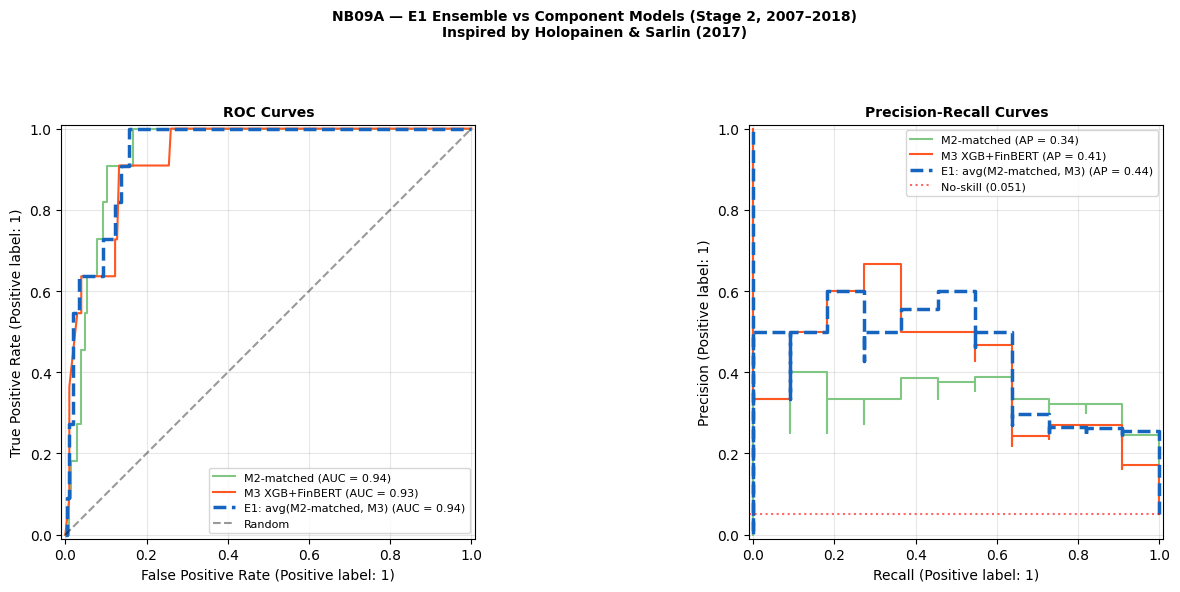

Saved -> C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\NB09A_ensemble_stage2.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'NB09A — E1 Ensemble vs Component Models (Stage 2, 2007–2018)\n'
    'Inspired by Holopainen & Sarlin (2017)',
    fontweight='bold', fontsize=10
)

plot_specs = [
    ('M2-matched',              e1['prob_m2m'], y_e1, '#81C784', '-',  1.5),
    ('M3 XGB+FinBERT',          e1['prob_m3'],  y_e1, '#FF5722', '-',  1.5),
    ('E1: avg(M2-matched, M3)', e1['prob_e1'],  y_e1, '#1565C0', '--', 2.5),
]

for name, probs, ys, col, ls, lw in plot_specs:
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=axes[0],
                                     color=col, linestyle=ls, linewidth=lw)
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=axes[1],
                                            color=col, linestyle=ls, linewidth=lw)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curves', fontweight='bold', fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].axhline(e1[TARGET].mean(), color='red', linestyle=':', alpha=0.6,
                label=f'No-skill ({e1[TARGET].mean():.3f})')
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=10)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
fig_path = FIG_DIR / 'NB09A_ensemble_stage2.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

## Cell 9 — Exploratory cross-stage ensembles (EXCLUDED from primary results)

**Status: Exploratory robustness check only. These results do NOT appear in Table 4.2.**

E2 and E3 combine models trained on different data windows (1988–2020 for Stage 1;  
2003–2020 for Stage 2). This violates the comparability assumption required for valid  
model averaging and means these variants cannot be interpreted as controlled ensemble tests.

E3 additionally includes M1, which exhibits systematic calibration mismatch in the  
cross-stage overlap window (mean probability 0.45 vs 0.17 for Stage 2 models,  
confirmed by Brier Score deterioration to 0.080). E3 is computed here to demonstrate  
this disqualification, not to report as a result.

In [19]:
# Cross-stage inner merge on (year, iso)
s1_slim = s1_eval[['year','iso',TARGET,'prob_m1','prob_m2']].rename(
    columns={TARGET: f'{TARGET}_s1'})
s2_slim = s2_eval[['year','iso',TARGET,'prob_m2m','prob_m3']]
overlap = pd.merge(s1_slim, s2_slim, on=['year','iso'], how='inner')
overlap = overlap.dropna(subset=['prob_m1','prob_m2','prob_m2m','prob_m3'])

mismatch = (overlap[TARGET] != overlap[f'{TARGET}_s1']).sum()
if mismatch > 0:
    print(f'WARNING: {mismatch} target mismatches — investigate before using overlap data.')
else:
    print('Targets consistent in overlap window.')
overlap = overlap.drop(columns=[f'{TARGET}_s1'])

overlap['prob_e2'] = (overlap['prob_m2'] + overlap['prob_m2m'] + overlap['prob_m3']) / 3
overlap['prob_e3'] = (overlap['prob_m1'] + overlap['prob_m2'] +
                      overlap['prob_m2m'] + overlap['prob_m3']) / 4

y_ovl = overlap[TARGET].values

ctx_b_results = [
    compute_metrics(y_ovl, overlap['prob_m1'].values,   'M1 LR (S1, extended)'),
    compute_metrics(y_ovl, overlap['prob_m2'].values,   'M2 RF (S1, extended)'),
    compute_metrics(y_ovl, overlap['prob_m2m'].values,  'M2-matched (S2)'),
    compute_metrics(y_ovl, overlap['prob_m3'].values,   'M3 XGB+FinBERT (S2)'),
    compute_metrics(y_ovl, overlap['prob_e2'].values,   'E2: avg(M2,M2m,M3) [exploratory only]'),
    compute_metrics(y_ovl, overlap['prob_e3'].values,   'E3: avg(M1,M2,M2m,M3) [M1 miscal, disqualified]'),
]
df_b = pd.DataFrame(ctx_b_results)

print()
print('=' * 105)
print(' EXPLORATORY — Cross-stage overlap  |  NOT reported in primary results')
print(f' Obs: {len(overlap)}  |  Crisis: {int(overlap[TARGET].sum())}  |  Base rate: {overlap[TARGET].mean():.4f}')
print(' Models trained on DIFFERENT data windows — not a controlled comparison.')
print('=' * 105)
print(f' {"Model":<52} {"AUROC":>7} {"AUPRC":>7} {"Brier":>7} {"Lift":>5}')
print('-' * 105)
for _, r in df_b.iterrows():
    flag = ' <-- Brier deterioration confirms miscalibration' if 'disqualified' in r.Label else ''
    print(f' {r.Label:<52} {r.AUROC:>7.4f} {r.AUPRC:>7.4f} {r.Brier:>7.4f} {r.AUPRC_lift:>5.1f}x{flag}')
print('=' * 105)
print()
print('NOTE: E2 (AUPRC 0.4739) is the highest in the exploratory table but is not')
print('      reportable as a primary result. It may be cited in a dissertation footnote')
print('      as indicative evidence that extended macro history (M2 Stage 1) carries')
print('      complementary signal to Stage 2 models, subject to the cross-stage caveats.')

Targets consistent in overlap window.

 EXPLORATORY — Cross-stage overlap  |  NOT reported in primary results
 Obs: 215  |  Crisis: 11  |  Base rate: 0.0512
 Models trained on DIFFERENT data windows — not a controlled comparison.
 Model                                                  AUROC   AUPRC   Brier  Lift
---------------------------------------------------------------------------------------------------------
 M1 LR (S1, extended)                                  0.7643  0.1958  0.2401   3.8x
 M2 RF (S1, extended)                                  0.9193  0.3540  0.0609   6.9x
 M2-matched (S2)                                       0.9385  0.3428  0.0602   6.7x
 M3 XGB+FinBERT (S2)                                   0.9316  0.4110  0.0608   8.0x
 E2: avg(M2,M2m,M3) [exploratory only]                 0.9452  0.4739  0.0563   9.3x
 E3: avg(M1,M2,M2m,M3) [M1 miscal, disqualified]       0.9323  0.4680  0.0799   9.1x <-- Brier deterioration confirms miscalibration

NOTE: E2 (AUPRC 0.473

## Cell 10 — Save all results and completion summary

In [21]:
all_records = []
for r in ctx_a_results:
    all_records.append({**r, 'Context': 'A_primary_stage2',
                        'n_obs': len(e1), 'n_crisis': int(e1[TARGET].sum())})
for r in ctx_b_results:
    all_records.append({**r, 'Context': 'B_exploratory_crossstage',
                        'n_obs': len(overlap), 'n_crisis': int(overlap[TARGET].sum())})

df_results = pd.DataFrame(all_records).round(4)
results_path = OUT_DIR / 'oos_predictions_ensemble.csv'
df_results.to_csv(results_path, index=False)
print(f'Results saved -> {results_path}')
print()

print('=' * 65)
print(' NB09A ENSEMBLE EXTENSION COMPLETE')
print('=' * 65)
print()
print('PRIMARY RESULT (for Chapter 4 Table 4.2 — new row):')
print(f'  E1  AUROC={e1_r.AUROC:.4f}  AUPRC={e1_r.AUPRC:.4f}  Brier={e1_r.Brier:.4f}')
print(f'  vs M2-matched : AUPRC delta {e1_r.AUPRC - m2m_r.AUPRC:+.4f} ({100*(e1_r.AUPRC/m2m_r.AUPRC-1):.1f}%)')
print(f'  vs M3         : AUPRC delta {e1_r.AUPRC - m3_r.AUPRC:+.4f}')
print()
print('CHAPTER 4 CHANGES REQUIRED:')
print('  Table 4.2   — add E1 row')
print('  Section 4.2 — add ~150 word paragraph after H1 verdict')
print('  Section 4.9 — one sentence update to H1 row in Table 4.6')
print('  Footnote    — note E2 exploratory finding with full caveats')
print()
print('FILES SAVED:')
for f in [results_path,
           FIG_DIR / 'NB09A_ensemble_stage2.png',
           FIG_DIR / 'NB09A_ensemble_disagreement.png']:
    p = Path(f)
    size = p.stat().st_size // 1024 if p.exists() else 0
    print(f'  {p.name}  ({size} KB)')

Results saved -> C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis\oos_predictions_ensemble.csv

 NB09A ENSEMBLE EXTENSION COMPLETE

PRIMARY RESULT (for Chapter 4 Table 4.2 — new row):
  E1  AUROC=0.9430  AUPRC=0.4396  Brier=0.0566
  vs M2-matched : AUPRC delta +0.0968 (28.3%)
  vs M3         : AUPRC delta +0.0285

CHAPTER 4 CHANGES REQUIRED:
  Table 4.2   — add E1 row
  Section 4.2 — add ~150 word paragraph after H1 verdict
  Section 4.9 — one sentence update to H1 row in Table 4.6
  Footnote    — note E2 exploratory finding with full caveats

FILES SAVED:
  oos_predictions_ensemble.csv  (1 KB)
  NB09A_ensemble_stage2.png  (110 KB)
  NB09A_ensemble_disagreement.png  (170 KB)


 2007 COUNTRY PROBABILITY RANKING — M4 ensemble
 Sorted by M4 (prob_e1) descending. Crisis type: qualitative annotation.
 crisis=1 denotes target_h2 positive (crisis onset within 2 years of 2007).
 Rank   ISO  crisis     M2m      M3      M4  Type              Note
---------------------------------------------------------------------------------------------------------
    1   FRA       1   0.674   1.000   0.837  Fundamental       Credit expansion, cross-border wholesale exposure <--
    2   ESP       1   0.622   0.865   0.744  Fundamental       Construction and credit boom; crisis onset delayed to 2012 <--
    3   PRT       1   0.418   0.970   0.694  Fundamental       External imbalance, sovereign-bank nexus; onset 2008 <--
    4   USA       0   0.613   0.750   0.682  Fundamental       Credit boom, subprime origination, securitisation
    5   SWE       1   0.583   0.750   0.667  No crisis         Strong bank capital; limited subprime exposure <--
    6   DNK       1   0.581   0.750   0

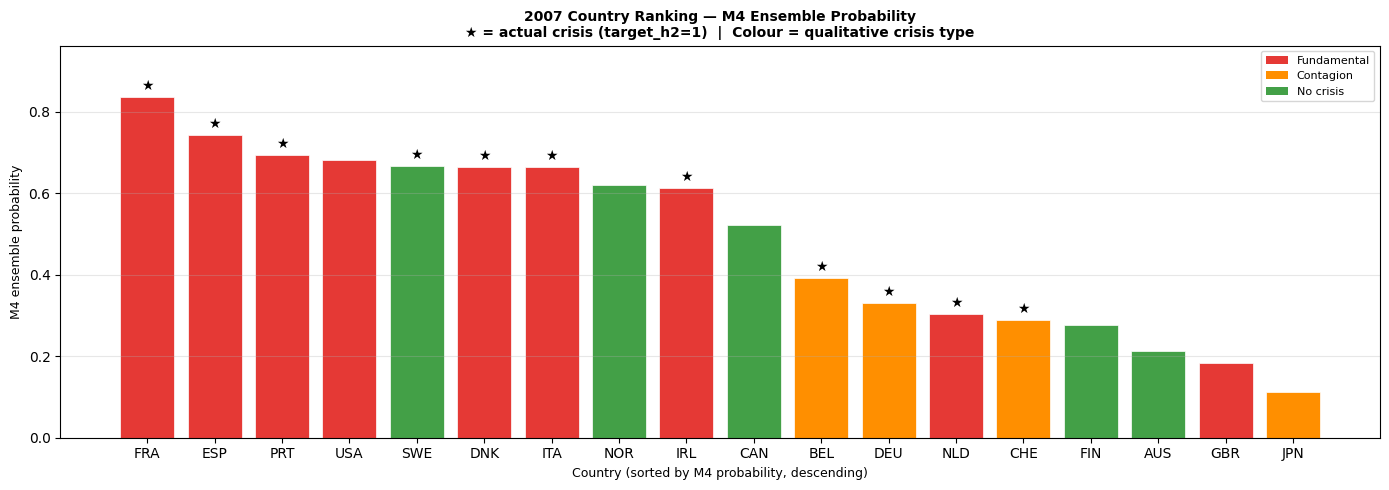

Saved -> C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis\NB09A_2007_country_ranking.png


In [38]:
## # ── Cell 11 — 2007 Country Probability Ranking with Crisis Type Annotation ──
#
# Purpose: Assess whether M4 assigns systematically higher probabilities to
# countries whose 2007 stress was fundamental (credit-boom driven) versus
# contagion-driven or exogenous. This is a retrospective qualitative check,
# not a formal crisis type classifier.
#
# Crisis type labels follow Laeven & Valencia (2020) and Reinhart & Rogoff (2009).
# Annotation is qualitative; crisis_type reflects dominant mechanism, not
# a mutually exclusive classification.

CRISIS_TYPE_2007 = {
    # iso   : (crisis_type_label,          brief_note)
    'USA'  : ('Fundamental',    'Credit boom, subprime origination, securitisation'),
    'GBR'  : ('Fundamental',    'Credit boom, wholesale funding dependence (Northern Rock)'),
    'IRL'  : ('Fundamental',    'Credit boom, property bubble, bank overleverage'),
    'DEU'  : ('Contagion',      'Landesbanken exposure to US ABS; limited domestic imbalance'),
    'FRA'  : ('Fundamental',    'Credit expansion, cross-border wholesale exposure'),
    'BEL'  : ('Contagion',      'Dexia/Fortis cross-border exposure; limited domestic boom'),
    'NLD'  : ('Fundamental',    'Credit and housing boom, cross-border bank expansion'),
    'CHE'  : ('Contagion',      'UBS ABS exposure; Swiss domestic fundamentals sound'),
    'ESP'  : ('Fundamental',    'Construction and credit boom; crisis onset delayed to 2012'),
    'ITA'  : ('Fundamental',    'Slow growth, sovereign-bank nexus; partial contagion'),
    'PRT'  : ('Fundamental',    'External imbalance, sovereign-bank nexus; onset 2008'),
    'AUS'  : ('No crisis',      'Sound macro fundamentals; no systemic event'),
    'CAN'  : ('No crisis',      'Conservative bank regulation; no systemic event'),
    'JPN'  : ('Contagion',      'Residual balance sheet weakness; GFC amplified existing stress'),
    'NOR'  : ('No crisis',      'Oil-driven fiscal surplus; limited exposure'),
    'SWE'  : ('No crisis',      'Strong bank capital; limited subprime exposure'),
    'DNK'  : ('Fundamental',    'Property and credit boom; small bank failures 2008'),
    'FIN'  : ('No crisis',      'Post-1991 restructured banking sector; resilient'),
}

# Build 2007 ranking table
df_2007 = e1[e1['year'] == 2007][
    ['iso', TARGET, 'prob_m2m', 'prob_m3', 'prob_e1']
].copy().sort_values('prob_e1', ascending=False).reset_index(drop=True)

df_2007['rank']         = df_2007.index + 1
df_2007['crisis_type']  = df_2007['iso'].map(lambda x: CRISIS_TYPE_2007.get(x, ('Unknown',''))[0])
df_2007['note']         = df_2007['iso'].map(lambda x: CRISIS_TYPE_2007.get(x, ('',''))[1])

print('=' * 105)
print(' 2007 COUNTRY PROBABILITY RANKING — M4 ensemble')
print(' Sorted by M4 (prob_e1) descending. Crisis type: qualitative annotation.')
print(' crisis=1 denotes target_h2 positive (crisis onset within 2 years of 2007).')
print('=' * 105)
print(f' {"Rank":>4}  {"ISO":>4}  {"crisis":>6}  {"M2m":>6}  {"M3":>6}  {"M4":>6}  {"Type":<16}  Note')
print('-' * 105)
for _, r in df_2007.iterrows():
    flag = ' <--' if r[TARGET] == 1 else ''
    print(f' {int(r["rank"]):>4}  {r.iso:>4}  {int(r[TARGET]):>6}  '
          f'{r.prob_m2m:>6.3f}  {r.prob_m3:>6.3f}  {r.prob_e1:>6.3f}  '
          f'{r.crisis_type:<16}  {r.note}{flag}')
print('=' * 105)
print()

# Summary statistics by crisis type
print('Summary — mean M4 probability by crisis type:')
print(df_2007.groupby('crisis_type')['prob_e1'].agg(['mean','min','max','count'])
      .round(3).sort_values('mean', ascending=False).to_string())
print()

# Discrimination check: do fundamental crises rank higher than contagion?
fundamental = df_2007[df_2007['crisis_type'] == 'Fundamental']['prob_e1']
contagion   = df_2007[df_2007['crisis_type'] == 'Contagion']['prob_e1']
no_crisis   = df_2007[df_2007['crisis_type'] == 'No crisis']['prob_e1']

print('Mean M4 probability by mechanism:')
print(f'  Fundamental : {fundamental.mean():.3f}  (n={len(fundamental)})')
print(f'  Contagion   : {contagion.mean():.3f}  (n={len(contagion)})')
print(f'  No crisis   : {no_crisis.mean():.3f}  (n={len(no_crisis)})')
print()
print('Interpretation:')
print('  If Fundamental >> Contagion >> No crisis:')
print('    M4 discriminates crisis type, not just crisis onset.')
print('  If Fundamental ~ Contagion:')
print('    M4 captures general stress rather than mechanism-specific signal.')
print('  If any No-crisis country ranks high:')
print('    Model generating false positives for macro-stressed but resilient economies.')

# Plot: ranked bar chart coloured by crisis type
fig, ax = plt.subplots(figsize=(14, 5))
type_colours = {
    'Fundamental': '#E53935',
    'Contagion':   '#FF8F00',
    'No crisis':   '#43A047',
    'Unknown':     '#9E9E9E',
}
bars = ax.bar(
    df_2007['iso'],
    df_2007['prob_e1'],
    color=[type_colours.get(t, '#9E9E9E') for t in df_2007['crisis_type']],
    edgecolor='white', linewidth=0.5
)
# Mark actual crisis countries
for i, (_, r) in enumerate(df_2007.iterrows()):
    if r[TARGET] == 1:
        ax.text(i, r.prob_e1 + 0.01, '★', ha='center', va='bottom',
                fontsize=10, color='black')

ax.set_xlabel('Country (sorted by M4 probability, descending)', fontsize=9)
ax.set_ylabel('M4 ensemble probability', fontsize=9)
ax.set_title(
    '2007 Country Ranking — M4 Ensemble Probability\n'
    '★ = actual crisis (target_h2=1)  |  Colour = qualitative crisis type',
    fontweight='bold', fontsize=10
)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in type_colours.items() if t != 'Unknown']
ax.legend(handles=legend_elements, fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, min(1.05, df_2007['prob_e1'].max() * 1.15))

plt.tight_layout()
fig_path_2007 = FIG_DIR / 'NB09A_2007_country_ranking.png'
fig.savefig(fig_path_2007, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path_2007}')